## Modelo base (baseline)

### By:
Bryan Escobar Restrepo

### Date:
2026-08-21

### Description:

Quinta etapa del proyecto (`5-models`). Establece el **punto de referencia contra el que
se van a comparar todos los modelos** que se entrenen después, siguiendo los pasos de
<https://joserzapata.github.io/post/ciencia-datos-proyecto-python/5-baseline_model/>.

Un modelo base sirve para responder una pregunta incómoda pero necesaria: *¿el modelo
complejo que voy a entrenar realmente aporta algo, o simplemente parece bueno porque
nunca lo comparé con nada?* Sin baseline, un R² de 0.79 no significa nada — puede ser
excelente o puede ser lo que consigue predecir siempre la media.

Se establecen **tres niveles de referencia**, no uno solo:

| Nivel | Modelo | Qué responde |
|---|---|---|
| Piso absoluto | `DummyRegressor` | ¿el modelo aprendió *algo*? |
| Base del proyecto | heurística de `03.3` como estimador | ¿supera lo que una persona haría a mano? |
| Valor añadido | regresión con **una sola variable** | ¿justifican las 7 variables su costo? |

Contenido: pipeline de `4-feat_eng` reutilizado, partición train/test, evaluación con
cuatro métricas, validación cruzada repetida con media y desviación estándar, selección
justificada de la variable más importante, curvas de aprendizaje y de escalabilidad, y
las recomendaciones para la etapa de modelado.

## 📚 Import  libraries

In [1]:
# base libraries for data science
import sys
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import (
    KFold,
    RepeatedKFold,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

pd.set_option("display.max_columns", 60)

print(f"pandas       {pd.__version__}")
print(f"scikit-learn {sklearn.__version__}")

pandas       3.0.5
scikit-learn 1.9.0


## ⚙️ Configuración

In [2]:
def buscar_raiz_proyecto() -> Path:
    """Sube por el árbol de directorios hasta encontrar la raíz del repositorio."""
    marcadores = (".git", "pyproject.toml")
    actual = Path.cwd().resolve()
    for candidato in (actual, *actual.parents):
        if any((candidato / marcador).exists() for marcador in marcadores):
            return candidato
    return actual


RAIZ = buscar_raiz_proyecto()
sys.path.insert(0, str(RAIZ / "src"))

from data.transformaciones import a_tipos_sklearn, recortar_a_dominio  # noqa: E402
from model.heuristica import HeuristicaAdmision  # noqa: E402

ARCHIVO_DATOS = RAIZ / "data" / "02_intermediate" / "admisiones_type_fixed.parquet"
ARCHIVO_PIPELINE = RAIZ / "data" / "06_models" / "pipeline_preprocesamiento.joblib"
DIR_MODELOS = RAIZ / "data" / "06_models"
DIR_REPORTES = RAIZ / "data" / "08_reporting"
DIR_REPORTES.mkdir(parents=True, exist_ok=True)

TARGET = "chance_of_admit"
# los mismos parametros que en 04, para que las particiones sean identicas
PROPORCION_TEST = 0.25
SEMILLA = 42

sns.set_theme(style="whitegrid", palette="deep")
print(f"Datos    : {ARCHIVO_DATOS.relative_to(RAIZ)}")
print(f"Pipeline : {ARCHIVO_PIPELINE.relative_to(RAIZ)}")

Datos    : data/02_intermediate/admisiones_type_fixed.parquet
Pipeline : data/06_models/pipeline_preprocesamiento.joblib


## 💾 Load data

In [3]:
df = pd.read_parquet(ARCHIVO_DATOS)
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(float)

print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dimensiones: 471 filas x 8 columnas


,gre_score,toefl_score,university_rating,sop,lor,cgpa,research,chance_of_admit
0,337,118,4,4.5,4.5,9.65,True,0.92
1,324,107,4,4.0,4.5,8.87,True,0.76
2,316,104,3,3.0,3.5,8.0,True,0.72
3,322,110,3,3.5,2.5,8.67,True,0.8
4,314,103,2,2.0,3.0,8.21,False,0.65


## ✂️ Dividir los datos en Train / Test

Se repite **exactamente** la partición de `4-feat_eng` (misma proporción, misma semilla).
No es un detalle cosmético: si el conjunto de prueba cambiara entre notebooks, las
métricas de este baseline no serían comparables con las del pipeline ni con las de los
modelos que vengan después, y todo el punto de tener una referencia se perdería.

Para confirmarlo se compara contra la matriz que quedó guardada en
`data/05_model_input/`.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=PROPORCION_TEST, random_state=SEMILLA
)

X_train_guardado = pd.read_parquet(RAIZ / "data" / "05_model_input" / "X_train.parquet")
if X_train.shape != X_train_guardado.shape:
    raise ValueError("La particion no coincide con la guardada en 4-feat_eng")

print(f"train: {X_train.shape[0]} filas   test: {X_test.shape[0]} filas")
print(
    f"Coincide con la particion guardada en 4-feat_eng: {X_train.shape == X_train_guardado.shape}"
)
print(f"media del target -> train: {y_train.mean():.3f}   test: {y_test.mean():.3f}")

train: 353 filas   test: 118 filas
Coincide con la particion guardada en 4-feat_eng: True
media del target -> train: 0.722   test: 0.728


## 🔧 Usar el pipeline de procesamiento de la tarea anterior

El pipeline ajustado en `4-feat_eng` se carga desde su artefacto `.joblib` y se **clona**
con `sklearn.base.clone`.

El clonado no es un tecnicismo: `clone` devuelve un estimador **con los mismos
hiperparámetros pero sin ajustar**. Eso es justo lo que hace falta para la validación
cruzada, donde el preprocesamiento tiene que reajustarse dentro de cada pliegue —
calculando la mediana de imputación y la escala solo con los datos de entrenamiento de
ese pliegue. Si se reutilizara el pipeline ya ajustado, las medianas y escalas llevarían
información de todos los datos y las métricas saldrían optimistas.

In [5]:
pipeline_ajustado = joblib.load(ARCHIVO_PIPELINE)
preprocesador = clone(pipeline_ajustado)

print("Pasos del pipeline:", [nombre for nombre, _ in preprocesador.steps])
print("Transformadores por tipo de columna:")
for nombre, _, columnas in preprocesador.named_steps["columnas"].transformers:
    print(f"  {nombre:6s} -> {columnas}")

muestra_transformada = clone(preprocesador).fit(X_train, y_train).transform(X_test.head(3))
muestra_transformada.round(3)

Pasos del pipeline: ['tipos', 'dominio', 'columnas']
Transformadores por tipo de columna:
  num    -> ['gre_score', 'toefl_score', 'sop', 'lor', 'cgpa']
  ord    -> ['university_rating']
  bool   -> ['research']


,gre_score,toefl_score,sop,lor,cgpa,university_rating,research
55,0.323,-0.730,-0.365,-0.498,-1.499,-0.095,0.0
73,-0.206,0.090,1.110,0.608,0.779,0.767,1.0
33,2.089,1.075,0.619,0.608,1.731,1.629,1.0


## 🎯 Los modelos base

### `DummyRegressor`: el piso absoluto

Predice siempre el mismo valor, sin mirar los datos de entrada. Es el mínimo que
cualquier modelo debe superar: si un modelo no le gana a esto, no aprendió nada. Se
prueban dos estrategias, `mean` y `median`, porque con distribuciones asimétricas pueden
diferir (aquí el target es casi simétrico, así que deberían quedar parejas).

### Heurística de `03.3`: la base real del proyecto

La regla manual propuesta en el análisis exploratorio —normalizar cada variable a [0, 1]
por su dominio documentado y promediar— formalizada como estimador de scikit-learn en
`src/model/heuristica.py`, con tests. Es una referencia mucho más exigente que el dummy:
representa **lo que se conseguiría sin machine learning**, y por lo tanto es la que
determina si el proyecto justifica su existencia.

Consume los datos **crudos**, no la salida del pipeline: normalizar por dominio no tiene
sentido sobre variables ya estandarizadas. Como efecto secundario no necesita imputación,
porque promedia solo las columnas que tiene.

### Regresión con una sola variable: el criterio de valor añadido

Un modelo lineal sobre `cgpa` únicamente. Responde a la pregunta de si vale la pena
recolectar, validar y mantener siete variables cuando quizá una sola explica casi todo.

Se añade además una `Ridge` con las siete variables **como referencia**, no como modelo
base: es el resultado ya obtenido en `4-feat_eng` y sirve para ver cuánto espacio queda
entre el baseline y un modelo real.

In [6]:
def pipeline_una_variable(columna: str) -> Pipeline:
    """Pipeline mínimo que usa una sola columna, con su imputación adecuada."""
    estrategia = "most_frequent" if columna in ("university_rating", "research") else "median"
    return Pipeline(
        [
            ("tipos", FunctionTransformer(a_tipos_sklearn)),
            ("dominio", FunctionTransformer(recortar_a_dominio)),
            (
                "columnas",
                ColumnTransformer(
                    [
                        (
                            "unica",
                            Pipeline(
                                [
                                    ("imputar", SimpleImputer(strategy=estrategia)),
                                    ("escalar", StandardScaler()),
                                ]
                            ),
                            [columna],
                        )
                    ]
                ),
            ),
            ("modelo", LinearRegression()),
        ]
    )


MODELOS = {
    "1. dummy (media)": Pipeline(
        [("preparacion", clone(preprocesador)), ("modelo", DummyRegressor(strategy="mean"))]
    ),
    "2. dummy (mediana)": Pipeline(
        [("preparacion", clone(preprocesador)), ("modelo", DummyRegressor(strategy="median"))]
    ),
    "3. heuristica de 03.3": HeuristicaAdmision(recalibrar=True),
    "4. regresion solo con cgpa": pipeline_una_variable("cgpa"),
    "5. ridge 7 variables (referencia)": Pipeline(
        [("preparacion", clone(preprocesador)), ("modelo", Ridge(alpha=1.0))]
    ),
}

for nombre in MODELOS:
    print(nombre)

1. dummy (media)
2. dummy (mediana)
3. heuristica de 03.3
4. regresion solo con cgpa
5. ridge 7 variables (referencia)


## 📏 Evaluar con diferentes métricas

El problema es de **regresión** (el target es continuo en [0, 1]), así que no aplican
*accuracy*, precisión ni recall. Se usan cuatro métricas que miden cosas distintas, y
conviene tener claro qué aporta cada una:

| Métrica | Qué mide | Por qué está aquí |
|---|---|---|
| **MAE** | error absoluto medio | la más interpretable: "me equivoco en X puntos de probabilidad". Es la métrica principal |
| **RMSE** | error cuadrático medio | penaliza más los errores grandes; comparada con el MAE indica si hay fallos aislados graves |
| **R²** | varianza explicada | permite comparar con otros problemas; un dummy da ≈ 0 por definición |
| **MAPE** | error porcentual | error relativo al valor real: equivocarse 0.05 sobre 0.9 no es lo mismo que sobre 0.4 |

Se sigue usando **MAE como métrica principal**, por la razón que se documentó en
`notebooks/1-data`: el producto muestra una probabilidad al aspirante, y el error en esa
probabilidad es directamente lo que percibe el usuario.

## 🔁 Validación cruzada

Una sola partición train/test da **un** número, y ese número depende de qué filas cayeron
en cada lado. Con 471 filas, esa lotería importa.

`RepeatedKFold` con 5 pliegues y 5 repeticiones entrena 25 veces sobre particiones
distintas, lo que da 25 mediciones por métrica: su **media** estima el desempeño esperado
y su **desviación estándar** dice cuánta confianza merece esa estimación. Una diferencia
entre modelos menor que la desviación no es una diferencia.

Todo se hace sobre el conjunto de **entrenamiento**. El de prueba se reserva para el
final.

In [7]:
METRICAS = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
    "MAPE": "neg_mean_absolute_percentage_error",
}
validacion = RepeatedKFold(n_splits=5, n_repeats=5, random_state=SEMILLA)

filas_resultados = []
for nombre, modelo in MODELOS.items():
    resultado = cross_validate(
        modelo, X_train, y_train, cv=validacion, scoring=list(METRICAS.values()), n_jobs=-1
    )
    fila = {"modelo": nombre}
    for etiqueta, clave in METRICAS.items():
        valores = resultado[f"test_{clave}"]
        signo = -1 if clave.startswith("neg_") else 1
        fila[etiqueta] = signo * valores.mean()
        fila[f"{etiqueta}_std"] = valores.std()
    fila["tiempo_fit_ms"] = 1000 * resultado["fit_time"].mean()
    filas_resultados.append(fila)

resultados_cv = pd.DataFrame(filas_resultados).set_index("modelo")
resultados_cv[["MAE", "MAE_std", "RMSE", "R2", "R2_std", "MAPE", "tiempo_fit_ms"]].round(4)

,MAE,MAE_std,RMSE,R2,R2_std,MAPE,tiempo_fit_ms
modelo,,,,,,,
1. dummy (media),0.1146,0.0095,0.1427,-0.0163,0.0177,0.1786,91.7178
2. dummy (mediana),0.1147,0.0093,0.1427,-0.0177,0.0173,0.1798,65.0297
3. heuristica de 03.3,0.0613,0.0045,0.0822,0.6598,0.0472,0.0989,8.5164
4. regresion solo con cgpa,0.0520,0.0046,0.0689,0.7595,0.0481,0.0828,32.5215
5. ridge 7 variables (referencia),0.0468,0.0047,0.0639,0.7935,0.0419,0.0755,65.5929


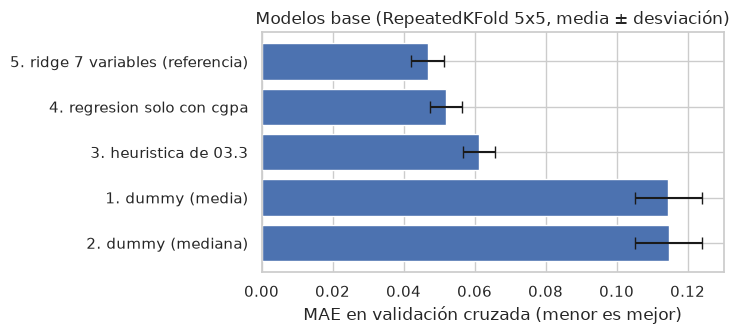

In [8]:
_, ax = plt.subplots(figsize=(7.5, 3.5))
orden = resultados_cv.sort_values("MAE", ascending=False)
ax.barh(orden.index, orden["MAE"], xerr=orden["MAE_std"], capsize=4)
ax.set_xlabel("MAE en validación cruzada (menor es mejor)")
ax.set_title("Modelos base (RepeatedKFold 5x5, media ± desviación)")
plt.tight_layout()
plt.show()

**Lectura de la tabla:**

| Modelo | MAE | R² | Lectura |
|---|---|---|---|
| dummy (media) | 0.1146 ± 0.0095 | −0.016 | el piso: R² negativo porque no explica nada y ni siquiera acierta la media exacta de cada pliegue |
| dummy (mediana) | 0.1147 ± 0.0093 | −0.018 | idéntico al anterior, como se esperaba de un target casi simétrico |
| heurística de `03.3` | 0.0613 ± 0.0045 | 0.660 | **47 % mejor que el dummy** sin entrenar nada |
| regresión solo con `cgpa` | 0.0520 ± 0.0046 | 0.760 | una sola variable ya llega muy lejos |
| ridge 7 variables (referencia) | 0.0468 ± 0.0047 | 0.794 | el modelo completo |

Y el dato que más condiciona el resto del proyecto: **entre usar solo `cgpa` y usar las
siete variables hay 0.005 de MAE**, exactamente del tamaño de la desviación estándar
entre pliegues. Las otras seis variables aportan, juntas, una mejora que está en el
límite de lo medible.

La desviación estándar también dice algo: los dummy tienen la mayor (±0.0095), porque su
error depende por completo de qué filas cayeron en cada pliegue. Los modelos que sí
aprenden son más estables.

## ⭐ Seleccionar la variable más importante

El enunciado pide elegir **una** variable y justificarlo. Un solo criterio puede engañar,
así que se usan tres métodos independientes: si los tres coinciden, la conclusión es
sólida.

In [9]:
validacion_rapida = RepeatedKFold(n_splits=5, n_repeats=3, random_state=SEMILLA)

filas_univariable = []
for columna in X.columns:
    puntajes = cross_validate(
        pipeline_una_variable(columna),
        X_train,
        y_train,
        cv=validacion_rapida,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
    )["test_score"]
    filas_univariable.append(
        {"variable": columna, "MAE_sola": -puntajes.mean(), "desv_est": puntajes.std()}
    )

univariable = pd.DataFrame(filas_univariable).set_index("variable").sort_values("MAE_sola")
univariable.round(4)

,MAE_sola,desv_est
variable,,
cgpa,0.0521,0.0048
gre_score,0.0638,0.0051
toefl_score,0.0651,0.0060
university_rating,0.0765,0.0052
sop,0.0806,0.0086
lor,0.0875,0.0074
research,0.0953,0.0083


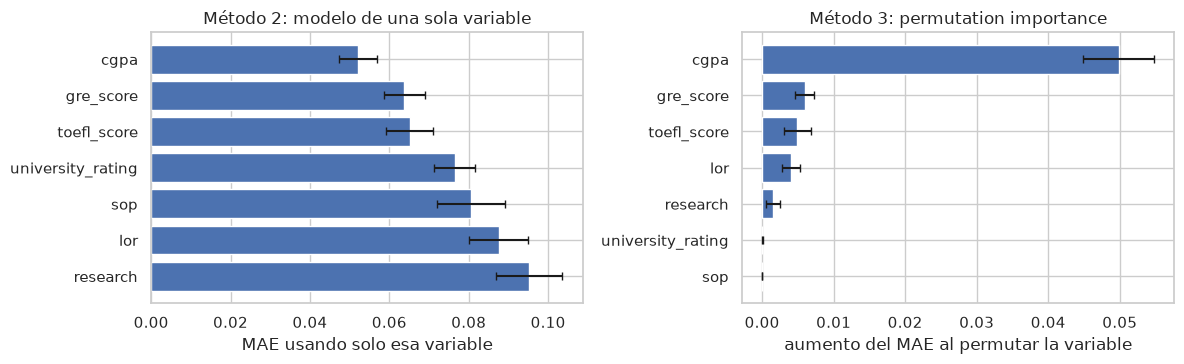

,aumento_del_MAE,desv_est
variable,,
cgpa,0.0499,0.0050
gre_score,0.0060,0.0013
toefl_score,0.0049,0.0019
lor,0.0040,0.0013
research,0.0015,0.0009
university_rating,0.0000,0.0001
sop,-0.0000,0.0000


In [10]:
modelo_referencia = Pipeline([("preparacion", clone(preprocesador)), ("modelo", Ridge(alpha=1.0))])
modelo_referencia.fit(X_train, y_train)

importancia = permutation_importance(
    modelo_referencia,
    X_test,
    y_test,
    n_repeats=30,
    random_state=SEMILLA,
    scoring="neg_mean_absolute_error",
)
permutacion = (
    pd.DataFrame(
        {
            "variable": X.columns,
            "aumento_del_MAE": importancia.importances_mean,
            "desv_est": importancia.importances_std,
        }
    )
    .set_index("variable")
    .sort_values("aumento_del_MAE", ascending=False)
)

_, axes = plt.subplots(1, 2, figsize=(12, 3.8))
orden_uni = univariable.sort_values("MAE_sola", ascending=False)
axes[0].barh(orden_uni.index, orden_uni["MAE_sola"], xerr=orden_uni["desv_est"], capsize=3)
axes[0].set_xlabel("MAE usando solo esa variable")
axes[0].set_title("Método 2: modelo de una sola variable")
orden_perm = permutacion.sort_values("aumento_del_MAE")
axes[1].barh(
    orden_perm.index, orden_perm["aumento_del_MAE"], xerr=orden_perm["desv_est"], capsize=3
)
axes[1].set_xlabel("aumento del MAE al permutar la variable")
axes[1].set_title("Método 3: permutation importance")
plt.tight_layout()
plt.show()

permutacion.round(4)

### La variable elegida es `cgpa`, y los tres métodos coinciden

| Método | Qué mide | Resultado |
|---|---|---|
| 1. Asociación con el target (`03.2`) | correlación de Spearman | `cgpa` **0.881**, seguida de `gre_score` 0.820 |
| 2. Modelo de una sola variable | MAE usando únicamente esa columna | `cgpa` **0.0521**, seguida de `gre_score` 0.0638 |
| 3. *Permutation importance* | cuánto empeora el modelo completo al desordenar esa columna | `cgpa` **+0.0499**, seguida de `gre_score` +0.0060 |

El tercer método es el más contundente: permutar `cgpa` degrada el MAE **ocho veces más**
que permutar la siguiente variable. Las demás son casi intercambiables entre sí y
`sop`/`university_rating` no cambian nada, porque su información ya está contenida en las
que quedan — es la multicolinealidad documentada en `03.2` (VIF hasta 5.06) vista desde
el otro lado.

**Por qué tiene sentido más allá de los números:** el `cgpa` es el promedio acumulado de
varios años de carrera. Frente al GRE o el TOEFL, que miden el desempeño de un día, un
promedio de carrera resume mucha más información sobre el aspirante — y es exactamente lo
que un comité de admisión mira primero.

**Advertencia sobre `permutation importance` con variables correlacionadas:** cuando dos
columnas están muy correlacionadas, permutar una sola puede subestimar su importancia,
porque el modelo compensa con la otra. Eso explica el 0.0000 de `university_rating`: no
significa que sea inútil (sola alcanza MAE 0.0765, mejor que el dummy), sino que es
redundante dado el resto. Por eso el método 2 acompaña al 3.

## 📈 Curvas de aprendizaje y escalabilidad

Una curva de aprendizaje entrena el mismo modelo con porciones crecientes de datos y
mide el error en entrenamiento y en validación. Lo que revela no es el desempeño, sino
**qué está limitando al modelo**, y eso decide qué hacer a continuación:

| Forma de la curva | Diagnóstico | Qué hacer |
|---|---|---|
| Las dos curvas convergen en un error alto | *underfitting*: el modelo es demasiado simple o faltan variables | más atributos o un modelo más flexible |
| Hay una brecha grande entre train y validación | *overfitting*: el modelo memoriza | más datos, regularización o un modelo más simple |
| La curva de validación sigue bajando al final | faltan datos | conseguir más filas |
| La curva de validación se aplana | más datos del mismo tipo no ayudarán | cambiar de variables o de modelo |

Se añaden los dos gráficos de **escalabilidad** que pide el enunciado: tiempo de
entrenamiento frente al número de muestras, y desempeño frente a tiempo de
entrenamiento.

In [11]:
TALLAS_ENTRENAMIENTO = np.linspace(0.1, 1.0, 8)
MODELOS_CURVA = {
    "dummy (media)": MODELOS["1. dummy (media)"],
    "heuristica de 03.3": MODELOS["3. heuristica de 03.3"],
    "regresion solo con cgpa": MODELOS["4. regresion solo con cgpa"],
    "ridge 7 variables": MODELOS["5. ridge 7 variables (referencia)"],
}


def curva_de_aprendizaje(modelo, X_datos: pd.DataFrame, y_datos: pd.Series) -> dict:
    """Ejecuta learning_curve devolviendo errores (MAE) y tiempos de ajuste."""
    tallas, puntaje_train, puntaje_validacion, tiempos_fit, _ = learning_curve(
        modelo,
        X_datos,
        y_datos,
        train_sizes=TALLAS_ENTRENAMIENTO,
        cv=KFold(n_splits=5, shuffle=True, random_state=SEMILLA),
        scoring="neg_mean_absolute_error",
        return_times=True,
        n_jobs=-1,
    )
    return {
        "tallas": tallas,
        "mae_train": -puntaje_train.mean(axis=1),
        "mae_validacion": -puntaje_validacion.mean(axis=1),
        "desv_validacion": puntaje_validacion.std(axis=1),
        "tiempo_fit": tiempos_fit.mean(axis=1),
    }


inicio = time.time()
curvas = {
    nombre: curva_de_aprendizaje(modelo, X_train, y_train)
    for nombre, modelo in MODELOS_CURVA.items()
}
print(f"Curvas calculadas en {time.time() - inicio:.1f} s")

Curvas calculadas en 1.5 s


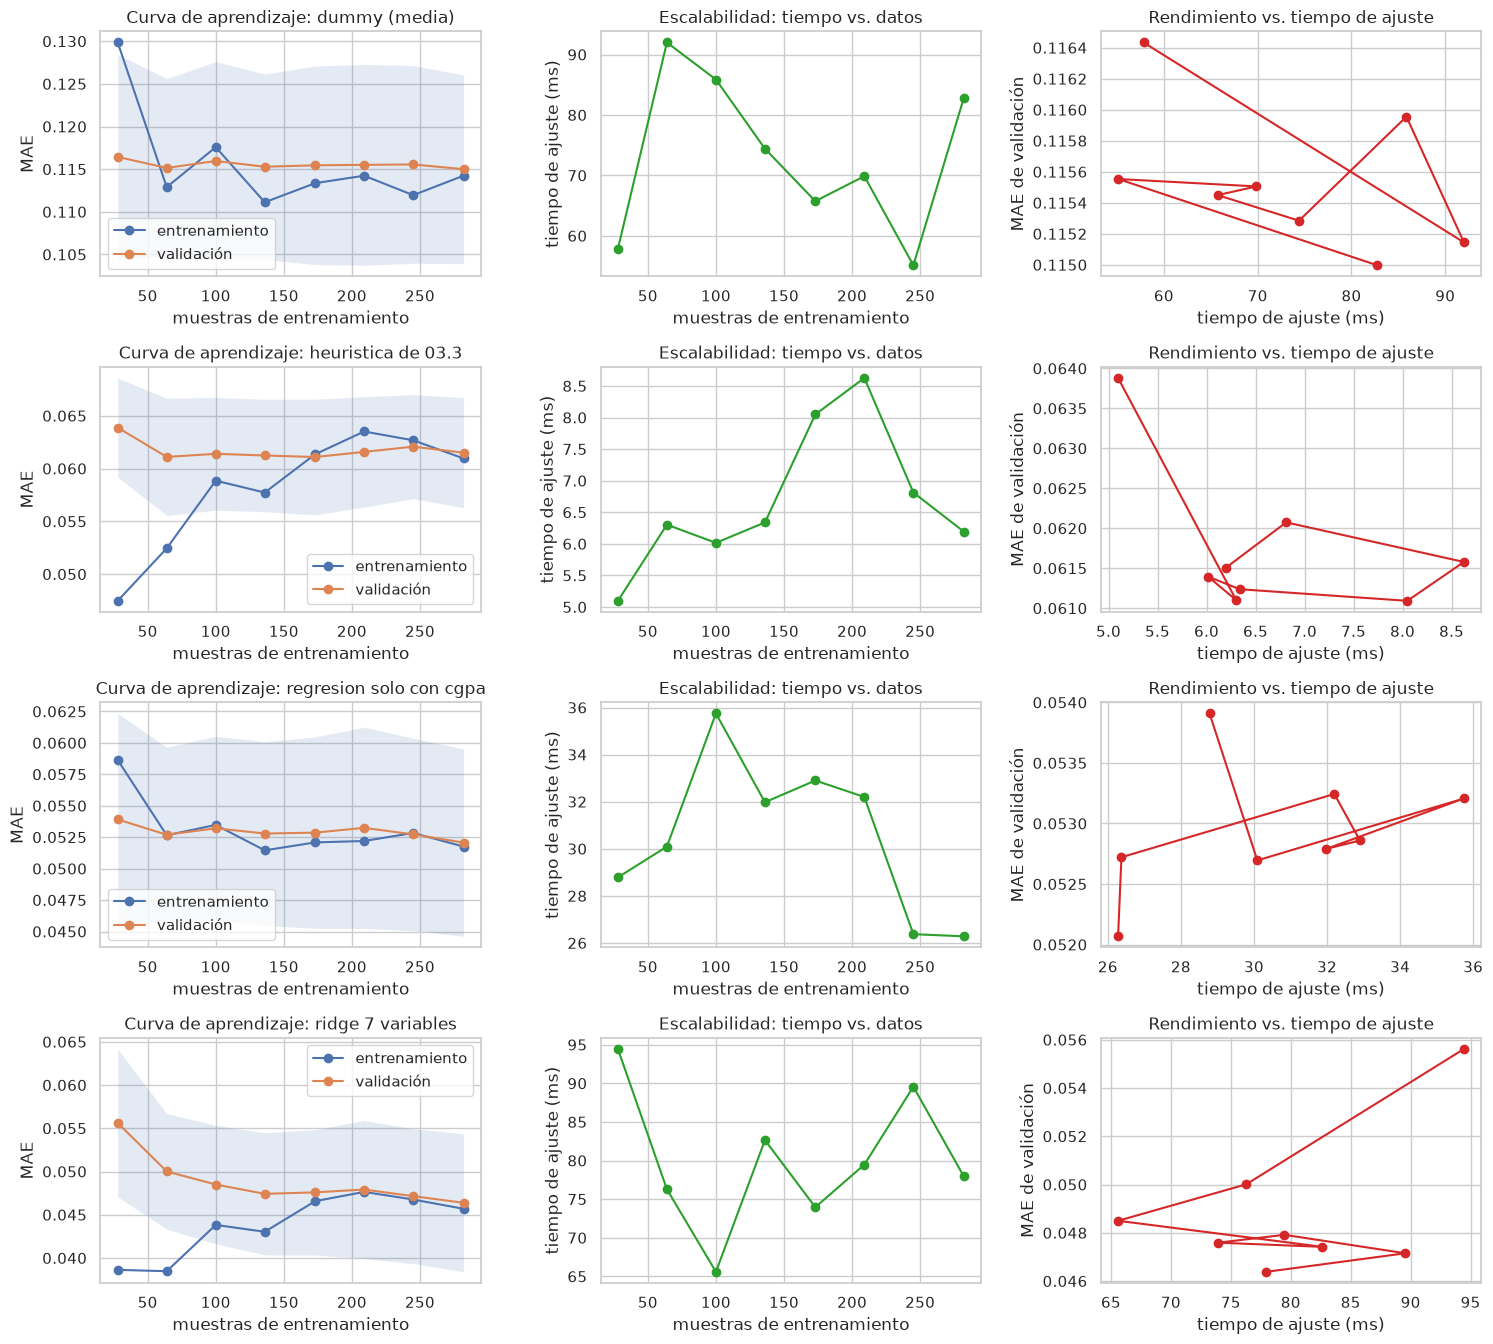

In [12]:
figura, axes = plt.subplots(len(curvas), 3, figsize=(15, 3.4 * len(curvas)))
for fila, (nombre, curva) in enumerate(curvas.items()):
    ax_error, ax_tiempo, ax_escala = axes[fila]

    ax_error.plot(curva["tallas"], curva["mae_train"], "o-", label="entrenamiento")
    ax_error.plot(curva["tallas"], curva["mae_validacion"], "o-", label="validación")
    ax_error.fill_between(
        curva["tallas"],
        curva["mae_validacion"] - curva["desv_validacion"],
        curva["mae_validacion"] + curva["desv_validacion"],
        alpha=0.15,
    )
    ax_error.set_xlabel("muestras de entrenamiento")
    ax_error.set_ylabel("MAE")
    ax_error.set_title(f"Curva de aprendizaje: {nombre}")
    ax_error.legend()

    ax_tiempo.plot(curva["tallas"], 1000 * curva["tiempo_fit"], "o-", color="tab:green")
    ax_tiempo.set_xlabel("muestras de entrenamiento")
    ax_tiempo.set_ylabel("tiempo de ajuste (ms)")
    ax_tiempo.set_title("Escalabilidad: tiempo vs. datos")

    ax_escala.plot(1000 * curva["tiempo_fit"], curva["mae_validacion"], "o-", color="tab:red")
    ax_escala.set_xlabel("tiempo de ajuste (ms)")
    ax_escala.set_ylabel("MAE de validación")
    ax_escala.set_title("Rendimiento vs. tiempo de ajuste")

plt.tight_layout()
plt.show()

In [13]:
mae_por_talla = pd.DataFrame(
    {nombre: curva["mae_validacion"] for nombre, curva in curvas.items()},
    index=pd.Index(next(iter(curvas.values()))["tallas"], name="muestras_entrenamiento"),
)
print("MAE de validación según el número de muestras de entrenamiento:")
print(mae_por_talla.round(4).to_string())

resumen_curvas = pd.DataFrame(
    {
        nombre: {
            "MAE_train_final": curva["mae_train"][-1],
            "MAE_validacion_final": curva["mae_validacion"][-1],
            "brecha_train_validacion": curva["mae_validacion"][-1] - curva["mae_train"][-1],
            "mejora_desde_n_minimo": curva["mae_validacion"][0] - curva["mae_validacion"][-1],
            "tiempo_fit_ms": 1000 * curva["tiempo_fit"][-1],
        }
        for nombre, curva in curvas.items()
    }
).T
resumen_curvas.round(4)

MAE de validación según el número de muestras de entrenamiento:
                        dummy (media)  heuristica de 03.3  regresion solo con cgpa  ridge 7 variables
muestras_entrenamiento                                                                               
28                             0.1164              0.0639                   0.0539             0.0556
64                             0.1151              0.0611                   0.0527             0.0500
100                            0.1160              0.0614                   0.0532             0.0485
136                            0.1153              0.0612                   0.0528             0.0474
173                            0.1154              0.0611                   0.0529             0.0476
209                            0.1155              0.0616                   0.0532             0.0479
245                            0.1156              0.0621                   0.0527             0.0472
282               

,MAE_train_final,MAE_validacion_final,brecha_train_validacion,mejora_desde_n_minimo,tiempo_fit_ms
dummy (media),0.1142,0.1150,0.0008,0.0014,82.7737
heuristica de 03.3,0.0610,0.0615,0.0005,0.0024,6.1935
regresion solo con cgpa,0.0518,0.0521,0.0003,0.0018,26.2797
ridge 7 variables,0.0457,0.0464,0.0007,0.0092,77.9604


### Interpretación de las curvas

**El `dummy` es la lección de control:** su curva es plana en 0.115 desde la primera
medición. No aprende, y por eso no le importa cuántos datos reciba. Cualquier curva que
se parezca a esta indica que el modelo no está captando señal.

**La heurística converge de inmediato:** train y validación se juntan alrededor de 0.061
a partir de ~64 muestras. Tiene sentido — solo aprende dos números (la recalibración
`a + b`), así que no hay capacidad que saturar. Es el retrato de un modelo con
*underfitting* por diseño: sesgo alto, varianza mínima.

**Los dos modelos que sí aprenden muestran el mismo patrón, y es el hallazgo importante:**

- La **brecha entre entrenamiento y validación es mínima** (0.0007 para `ridge`). No hay
  *overfitting*: el modelo no está memorizando, y por lo tanto **no se gana nada
  regularizando más ni simplificando**.
- La curva de validación **se aplana** pronto. Para `ridge`, pasar de 28 a 136 muestras
  mejora el MAE en 0.0082, pero pasar de 136 a 282 lo mejora solo 0.0010 — y esa última
  cifra es cinco veces menor que la desviación entre pliegues. Es decir: **duplicar el
  dataset no mejoraría el modelo de forma apreciable**.

Las dos cosas juntas dicen que el techo no lo pone ni el tamaño del dataset ni la
complejidad del modelo, sino **la información contenida en las siete variables**. Encaja
exactamente con lo que mostró `3-analysis`: todas miden un mismo rasgo latente. Para
mejorar hay que conseguir variables nuevas, no más filas ni modelos más grandes.

**Escalabilidad:** los tiempos de ajuste van de 7 ms (heurística) a ~70 ms (pipeline
completo) y son **planos respecto al número de muestras**. Con 471 filas el costo está
dominado por el *overhead* de construir el pipeline, no por el volumen de datos; el ruido
entre mediciones es mayor que la tendencia. La conclusión práctica es que a esta escala
**el tiempo de cómputo no es una restricción** para elegir modelo — se puede elegir por
desempeño e interpretabilidad sin pensar en el costo. Habrá que rehacer esta medición si
el dataset crece varios órdenes de magnitud.

## 🏁 Evaluación final sobre el conjunto de prueba

Las decisiones ya están tomadas con validación cruzada sobre *train*. El conjunto de
prueba se toca **una sola vez**, para estimar sin sesgo el desempeño de cada referencia.

In [14]:
filas_test = []
for nombre, modelo in MODELOS.items():
    ajustado = clone(modelo).fit(X_train, y_train)
    prediccion = ajustado.predict(X_test)
    filas_test.append(
        {
            "modelo": nombre,
            "MAE": mean_absolute_error(y_test, prediccion),
            "RMSE": root_mean_squared_error(y_test, prediccion),
            "R2": r2_score(y_test, prediccion),
            "MAPE": mean_absolute_percentage_error(y_test, prediccion),
        }
    )

resultados_test = pd.DataFrame(filas_test).set_index("modelo")
resultados_test["mejora_vs_dummy_%"] = (
    100
    * (resultados_test.loc["1. dummy (media)", "MAE"] - resultados_test["MAE"])
    / resultados_test.loc["1. dummy (media)", "MAE"]
)
resultados_test.round(4)

,MAE,RMSE,R2,MAPE,mejora_vs_dummy_%
modelo,,,,,
1. dummy (media),0.1191,0.1465,-0.0017,0.1799,0.0000
2. dummy (mediana),0.1192,0.1464,-0.0002,0.1821,-0.1125
3. heuristica de 03.3,0.0643,0.0845,0.6667,0.1037,46.0545
4. regresion solo con cgpa,0.0501,0.0712,0.7634,0.0802,57.9489
5. ridge 7 variables (referencia),0.0485,0.0666,0.7934,0.0781,59.2822


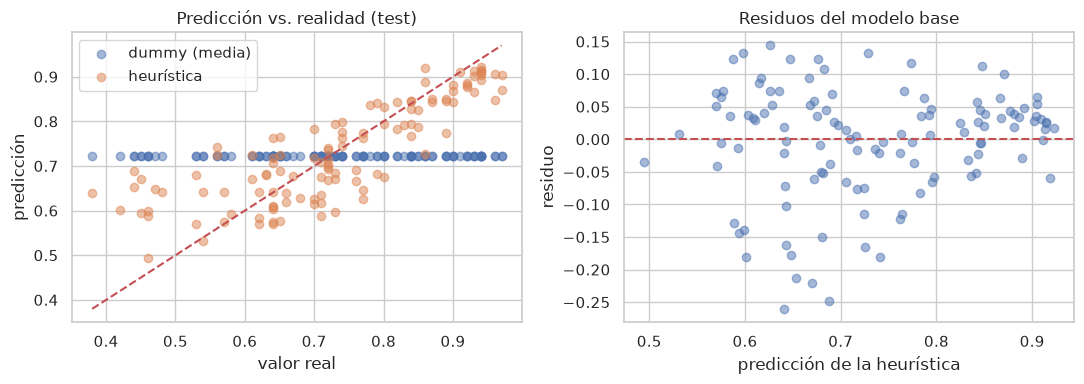

Residuo medio: -0.0040   |residuo| maximo: 0.260

Residuo medio por tercil del target (positivo = el modelo subestima):
                   mean  count
chance_of_admit               
target bajo     -0.0757     40
target medio     0.0289     40
target alto      0.0368     38


In [15]:
modelo_base = clone(MODELOS["3. heuristica de 03.3"]).fit(X_train, y_train)
prediccion_base = modelo_base.predict(X_test)
prediccion_dummy = clone(MODELOS["1. dummy (media)"]).fit(X_train, y_train).predict(X_test)

_, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_test, prediccion_dummy, alpha=0.5, label="dummy (media)")
axes[0].scatter(y_test, prediccion_base, alpha=0.5, label="heurística")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[0].set_xlabel("valor real")
axes[0].set_ylabel("predicción")
axes[0].set_title("Predicción vs. realidad (test)")
axes[0].legend()

residuos_base = y_test - prediccion_base
axes[1].scatter(prediccion_base, residuos_base, alpha=0.5)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_xlabel("predicción de la heurística")
axes[1].set_ylabel("residuo")
axes[1].set_title("Residuos del modelo base")
plt.tight_layout()
plt.show()

print(
    f"Residuo medio: {residuos_base.mean():.4f}   |residuo| maximo: {residuos_base.abs().max():.3f}"
)

# un residuo positivo significa que el modelo se quedo corto
tercil = pd.qcut(y_test, 3, labels=["target bajo", "target medio", "target alto"])
print("\nResiduo medio por tercil del target (positivo = el modelo subestima):")
print(residuos_base.groupby(tercil, observed=True).agg(["mean", "count"]).round(4).to_string())

El gráfico de la izquierda muestra de un vistazo por qué el dummy es solo un piso: sus
predicciones forman una línea horizontal (siempre el mismo valor) mientras que la
heurística sigue la diagonal.

En los residuos de la heurística se ve un patrón claro, y la tabla por terciles lo
cuantifica: **sobrestima a los aspirantes de probabilidad baja en 0.076 de media y
subestima a los de probabilidad alta en 0.037**. Es la firma de un modelo con sesgo,
esperable en una regla que pondera todas las variables por igual y que por construcción
tira hacia el centro. Un modelo entrenado corrige justo eso, y ahí está su valor
añadido.

## 💾 Guardar el modelo base y sus métricas

El modelo base no es un experimento desechable: es el **criterio de aceptación** de todo
lo que venga después. Se guarda junto a sus métricas para que `5-models` compare contra
un número registrado y no contra un recuerdo.

In [16]:
ARCHIVO_MODELO_BASE = DIR_MODELOS / "modelo_base_heuristica.joblib"
ARCHIVO_METRICAS = DIR_REPORTES / "metricas_modelo_base.parquet"

joblib.dump(modelo_base, ARCHIVO_MODELO_BASE)
metricas_para_guardar = resultados_test.join(resultados_cv[["MAE", "MAE_std"]].add_suffix("_cv"))
metricas_para_guardar.reset_index().to_parquet(ARCHIVO_METRICAS, index=False)

print(
    f"modelo base -> {ARCHIVO_MODELO_BASE.relative_to(RAIZ)} ({ARCHIVO_MODELO_BASE.stat().st_size / 1024:.1f} KB)"
)
print(f"metricas    -> {ARCHIVO_METRICAS.relative_to(RAIZ)}")

recargado = joblib.load(ARCHIVO_MODELO_BASE)
if not np.allclose(recargado.predict(X_test), prediccion_base):
    raise ValueError("El modelo base recargado no reproduce las mismas predicciones")
print("\nEl modelo base recargado reproduce las mismas predicciones.")
print(
    f"Coeficientes de la recalibracion: a = {recargado.coef_[0]:.3f}, b = {recargado.coef_[1]:.3f}"
)

modelo base -> data/06_models/modelo_base_heuristica.joblib (0.3 KB)
metricas    -> data/08_reporting/metricas_modelo_base.parquet

El modelo base recargado reproduce las mismas predicciones.
Coeficientes de la recalibracion: a = 0.277, b = 0.660


## 📊 Analysis of Results and Conclusions

**Resultados en el conjunto de prueba:**

| Modelo | MAE | RMSE | R² | MAPE | Mejora vs. dummy |
|---|---|---|---|---|---|
| dummy (media) | 0.1191 | 0.1465 | −0.002 | 18.0 % | — |
| dummy (mediana) | 0.1192 | 0.1464 | −0.000 | 18.2 % | −0.1 % |
| heurística de `03.3` | 0.0643 | 0.0845 | 0.667 | 10.4 % | **46 %** |
| regresión solo con `cgpa` | 0.0501 | 0.0712 | 0.763 | 8.0 % | **58 %** |
| ridge 7 variables (referencia) | 0.0485 | 0.0666 | 0.793 | 7.8 % | **59 %** |

**Conclusiones:**

1. **El baseline del proyecto queda fijado en MAE 0.0643** (heurística recalibrada). No
   se usa el dummy como referencia porque es demasiado fácil de superar: cualquier cosa
   le gana, y eso no informa. La pregunta útil no es "¿supero a predecir siempre la
   media?", sino "¿supero a lo que una persona haría con una calculadora?".
2. **Una sola variable, `cgpa`, deja al modelo completo casi sin margen.** En test,
   0.0501 frente a 0.0485 de MAE: las otras seis variables juntas aportan 0.0016. En
   validación cruzada la diferencia es algo mayor (0.0520 vs. 0.0468) pero sigue siendo
   del orden de la desviación entre pliegues (±0.005). Sea cual sea la estimación, el
   grueso de la señal está en una sola columna.
3. **No hay overfitting ni falta de datos.** Las curvas de aprendizaje convergen con una
   brecha de 0.0007 entre entrenamiento y validación, y la curva de validación se aplana
   a partir de ~140 muestras. El límite lo pone la información disponible en las
   variables, no el tamaño del dataset ni la capacidad del modelo.
4. **El tiempo de cómputo no es una restricción** a esta escala: todos los modelos se
   ajustan en menos de 100 ms y el tiempo es plano respecto al número de muestras.
5. **El modelo base tiene un sesgo medido:** sobrestima los perfiles de target bajo en
   0.076 y subestima los de target alto en 0.037. Ese es el hueco concreto que un modelo
   entrenado debe cerrar.

## 🎯 Recomendaciones para crear el modelo

1. **Criterio de aceptación: MAE < 0.0643 en test.** Un modelo que no supere la
   heurística no justifica el costo de entrenarlo, versionarlo y desplegarlo. El listón
   exigente es **0.0501**, el de la regresión con una sola variable: por debajo de eso, el
   modelo demuestra que las siete variables aportan algo real.
2. **Empezar por modelos simples y regularizados** (Ridge, Lasso, ElasticNet). Las curvas
   de aprendizaje descartan el *overfitting*, así que la complejidad extra tiene poco que
   ganar; y con la multicolinealidad documentada (VIF hasta 5.06), la regularización
   ayuda más a la estabilidad de los coeficientes que a la precisión.
3. **Probar un modelo de árboles** (`HistGradientBoosting`, Random Forest) por una razón
   concreta y no por moda: es el único candidato que captura sin ayuda la interacción
   `university_rating` × `research` documentada en `03.3`, y además tolera nulos de forma
   nativa.
4. **No invertir en recolectar más filas del mismo tipo.** La curva de validación ya está
   plana. El esfuerzo rinde mucho más consiguiendo variables nuevas — el ranking real de
   la universidad, el área de estudio, el resultado real de la admisión.
5. **Evaluar siempre con validación cruzada, no con una partición única.** Las
   desviaciones estándar de este notebook (±0.005) son del mismo orden que las
   diferencias entre modelos: sin CV, la comparación mide la suerte de la partición.
6. **Vigilar el sesgo en los extremos.** El MAE global esconde que los errores se
   concentran en los perfiles de probabilidad baja. Conviene reportar el error por
   tramos del target además del promedio.

## 💡 Proposals and Ideas

- **Añadir la métrica de ranking al conjunto de evaluación.** El producto ordena
  universidades en *segura / probable / ambiciosa* (`03.3`), así que un modelo con MAE
  ligeramente peor pero mejor Spearman podría ser preferible. Conviene decidir el criterio
  antes de comparar modelos, no después de ver los resultados.
- **Usar `GridSearchCV` sobre el pipeline completo**, incluyendo el preprocesamiento como
  hiperparámetro (imputación por mediana vs. moda, ordinal vs. one-hot): así se optimizan
  juntos preprocesamiento y modelo, sin fuga entre pliegues.
- **Mantener la heurística en producción como *fallback*.** No necesita imputación —
  promedia las columnas disponibles—, así que degrada con elegancia cuando a un aspirante
  le faltan datos, justo donde un modelo entrenado obligaría a imputar.
- **Registrar las métricas del baseline en el repositorio** (ya se hace en
  `data/08_reporting/metricas_modelo_base.parquet`) para que la comparación entre etapas
  sea automática y no dependa de recordar los números.
- **Un modelo por tramo del target** es una idea a evaluar con cautela: podría corregir el
  sesgo en los extremos, pero con 471 filas el riesgo de sobreajustar cada submodelo es
  alto.

## 📖 References

- Modelo base, Jose R. Zapata:
  <https://joserzapata.github.io/post/ciencia-datos-proyecto-python/5-baseline_model/>
- `sklearn.dummy`: <https://scikit-learn.org/stable/api/sklearn.dummy.html>
- Curvas de aprendizaje y escalabilidad:
  <https://scikit-learn.org/stable/modules/learning_curve.html>
- `permutation_importance` y su comportamiento con variables correlacionadas:
  <https://scikit-learn.org/stable/modules/permutation_importance.html>
- Heurística usada como modelo base: `src/model/heuristica.py`